### Support Vector Machine (SVM):

Banknote Authentication Data Set:

The Banknote Authentication Data Set is commonly used for classification tasks, particularly in machine learning, to distinguish between genuine and counterfeit banknotes.

Data are extracted from images that were taken for the evaluation of an authentication procedure for banknotes.

Images have 400 x 400 pixels.

Wavelet Transform tool is used to extract features from images.

The Wavelet Transform is a mathematical technique used to analyze signals or images by decomposing them into different frequency components while preserving spatial (or time) information. In the Banknote Authentication Data Set, wavelet transformation is applied to images of banknotes to extract features that help distinguish between genuine and counterfeit notes.

The Wavelet Transform (WT) is similar to the Fourier Transform, but instead of analyzing the entire signal at once, it uses small wave-like functions (wavelets) to analyze different parts of the signal at different resolutions.

- Traditional Fourier Transform: Converts a signal into sinusoidal waves but loses time/spatial information.
- Wavelet Transform: Uses short-duration wavelets to analyze both frequency and location details, making it effective for analyzing local features in an image.

Why Use Wavelet Transform for Banknote Authentication?
Banknotes contain complex textures, patterns, and fine details that are difficult to analyze using standard statistical techniques. Wavelet transformation helps extract meaningful features from these textures, allowing better discrimination between real and fake notes.

- How Wavelet Transform is Applied in Image Processing?
The wavelet transform typically follows these steps:

1. Decomposition: The image is broken into different frequency sub-bands (approximate and detailed components).
Commonly used method: Discrete Wavelet Transform (DWT), which splits the image into low-frequency (approximate) and high-frequency (detailed) components.

2. Feature Extraction: Statistical properties like variance, skewness, kurtosis, and entropy are calculated from the wavelet-transformed image.

3. Classification: These extracted features are used as input in machine learning models (like KNN, SVM, or logistic regression) to classify banknotes as genuine or counterfeit.

Here are the definitions of the terms you listed:

- Variance of Wavelet Transformed Image (Continuous):
Measures the spread or dispersion of pixel intensity values after applying a wavelet transformation to the banknote image.
High variance indicates more fluctuations in intensity, while low variance suggests a more uniform distribution.

- Skewness of Wavelet Transformed Image (Continuous):
Measures the asymmetry of the pixel intensity distribution in the transformed image.
A positive skewness indicates more weight on the left side of the distribution, while a negative skewness means more weight on the right.

- Kurtosis of Wavelet Transformed Image (Continuous):
Describes the tailedness of the pixel intensity distribution in the transformed image.
High kurtosis means more outliers and sharper peaks, while low kurtosis suggests a flatter distribution.

- Entropy of Image (Continuous):
Measures the randomness or disorder in the image data.
Higher entropy suggests more complexity, while lower entropy indicates a more structured or predictable image.

- Class (Integer):
The target label indicating whether the banknote is genuine (1) or counterfeit (0).

Our task here is to predict whether a bank currency note is authentic or not based upon four attributes of the note i.e. skewness of the wavelet transformed image, variance of the image, entropy of the image, and curtosis of the image. And, in the dataset we have another attribute that refers to the class 0 or 1. This is a binary classification problem and we will use SVM algorithm to solve this problem. The rest of the section consists of standard machine learning steps.

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
# importing the dataset
bankdata = pd.read_csv("bill_authentication.csv")

check the dimensions of the data and see first few records. To see the rows and columns and of the data, execute the method shape:
n the output you will see (1372,5). This means that the bank note dataset has 1372 rows and 5 columns.
To get a feel of how our dataset actually looks, execute the method head:
You can see that all of the attributes in the dataset are numeric. The label is also numeric i.e. 0 and 1.

In [3]:
bankdata.shape

(1372, 5)

In [4]:
bankdata.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In the cell number 5, all the columns of the bankdata dataframe are being stored in the X variable except the "Class" column, which is the label column. The drop() method drops this column. Then only the class column is being stored in the y variable. At this point of time X variable contains attributes while y variable contains corresponding labels.

In [5]:
# data preprocessing
X = bankdata.drop('Class', axis=1)
y = bankdata['Class']

In cell number 6, the model_selection library of the Scikit-Learn library contains the train_test_split method that allows us to seamlessly divide data into training and test sets.

In [6]:
# splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In cell number 7, we train our SVM on the training data. Scikit-Learn contains the svm library, which contains built-in classes for different SVM algorithms. Since we are going to perform a classification task, we will use the support vector classifier class, which is written as SVC in the Scikit-Learn's svm library. This class takes a parameter, which is the kernel type. This is very important. In the case of a simple SVM we simply set this parameter as "linear" since simple SVMs can only classify linearly separable data. We will see non-linear kernels in the next section.
The fit method of SVC class is called to train the algorithm on the training data, which is passed as a parameter to the fit method.

In [7]:
# training the data with SVM
from sklearn.svm import SVC
svclassifier = SVC(kernel='linear')
svclassifier.fit(X_train, y_train)

SVC(kernel='linear')

In cell number 8, To make predictions, the predict method of the SVC class is going to be used. 
In cell number 9, we evaluate the model SVM. Confusion matrix, accuracy, precision, recall, and F1 measures are the most commonly used metrics for classification tasks. Scikit-Learn's metrics library contains the classification_report and confusion_matrix methods, which can be used to find out the values for these important metrics.

In [8]:
# making predictions
y_pred = svclassifier.predict(X_test)

In [9]:
# evaluating the model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[153   3]
 [  4 115]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       156
           1       0.97      0.97      0.97       119

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275



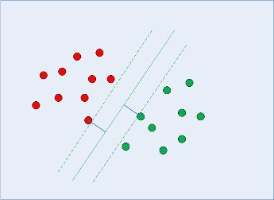

linearly separable data